In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/MyDrive/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/test.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cifar = pd.concat([df_train, df_test],axis = 0,ignore_index=True)

In [ ]:
print(cifar.shape)

(60000, 3073)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. CLEAN FIRST
# This removes any rows that have 'nan' in the label or pixels
cifar = cifar.dropna()

# 2. SEPARATE X and Y
X = cifar.drop('label', axis=1)
Y = cifar['label'].astype('int') # Ensure labels are whole numbers

# 3. SPLIT
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=101, test_size=0.20)



# print("Data is clean, split, and categorized!")

(48000, 3072)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Flatten
from keras.layers import Conv2D,MaxPooling2D
from keras.utils import to_categorical
from keras.optimizers import Adam
import tensorflow as tf


<function matplotlib.pyplot.show(close=None, block=None)>

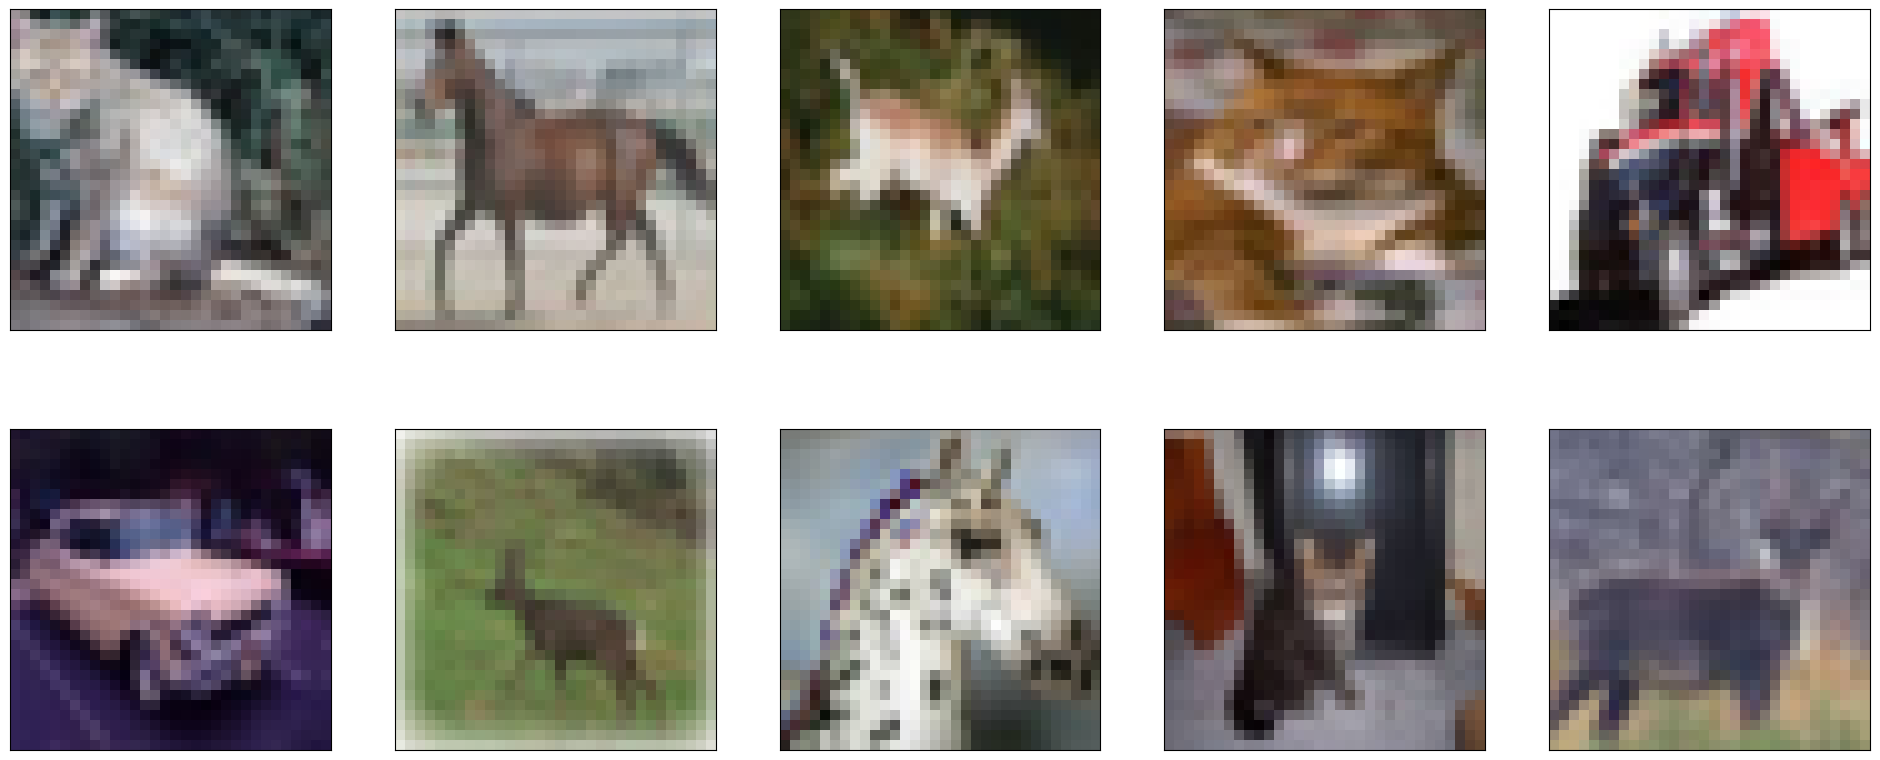

In [ ]:
n = 10
import matplotlib.pyplot as plt
plt.figure(figsize=(24,10))
for i in range(n):
  ax = plt.subplot(2,n//2,i+1)
  x_train_numpy = x_train.values if hasattr(x_train, 'values') else x_train
  plt.imshow(x_train_numpy[i].reshape(3,32,32).transpose(1,2,0))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show


# hasattr: Checks for the .values button so we don't crash.

# reshape: Turns a "string" of numbers into "square layers."

# transpose: Swaps the layers so "Color" is the last thing, making it a real picture.
# so listen what i get now as the data is in table foam we apply reshape to get the colors and then transponse them to  bind the colors and made the pixel and now tell me why there is need of hasattri and also explain the transponse parameters

In [ ]:
import numpy as np

print("y_train shape:", y_train.shape)
print("Unique values:", np.unique(y_train))
print("NaN count:", np.isnan(y_train).sum())
print("Inf count:", np.isinf(y_train).sum())
print("Negative values:", (y_train < 0).sum())
print("Max value:", y_train.max())
print("Min value:", y_train.min())

y_train shape: (40000,)
Unique values: [0 1 2 3 4 5 6 7 8 9]
NaN count: 0
Inf count: 0
Negative values: 0
Max value: 9
Min value: 0


In [ ]:
uniques,counts = np.unique(y_train,return_counts=True)
for value, count in zip(uniques, counts):
    print(f"Class {value}: {count} samples")

Class 0: 3975 samples
Class 1: 3984 samples
Class 2: 4035 samples
Class 3: 4035 samples
Class 4: 4053 samples
Class 5: 3974 samples
Class 6: 4007 samples
Class 7: 3978 samples
Class 8: 3960 samples
Class 9: 3999 samples


In [ ]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
x_train.shape

(40000, 3072)

In [ ]:
from keras.models import Sequential
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
x_train_numpy = x_train.values if hasattr(x_train, 'values') else x_train
x_test_numpy = x_test.values if hasattr(x_test, 'values') else x_test

# 2. Reshape and Transpose the WHOLE dataset
# (Number of samples, Channels, Height, Width) -> (Number of samples, Height, Width, Channels)
x_train = x_train_numpy.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test_numpy.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

x_train_split , x_val , y_train_split , y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=101)

history = model.fit(x_train_split,y_train_split,epochs=10,batch_size = 500 ,validation_data=(x_val,y_val))

test_loss , test_acc = model.evaluate(x_test ,y_test)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.2421 - loss: 2.0789 - val_accuracy: 0.4059 - val_loss: 1.6451
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4115 - loss: 1.6091 - val_accuracy: 0.4571 - val_loss: 1.4684
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4861 - loss: 1.4233 - val_accuracy: 0.5171 - val_loss: 1.3458
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5189 - loss: 1.3481 - val_accuracy: 0.5280 - val_loss: 1.3226
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5418 - loss: 1.2928 - val_accuracy: 0.5590 - val_loss: 1.2417
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5697 - loss: 1.2158 - val_accuracy: 0.5725 - val_loss: 1.2043
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5892 - loss: 1.1649 - val_accuracy: 0.5929 - val_loss: 1.1495
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6110 - loss: 1.1122 - val_accuracy: 0.5956 - v

In [ ]:
pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


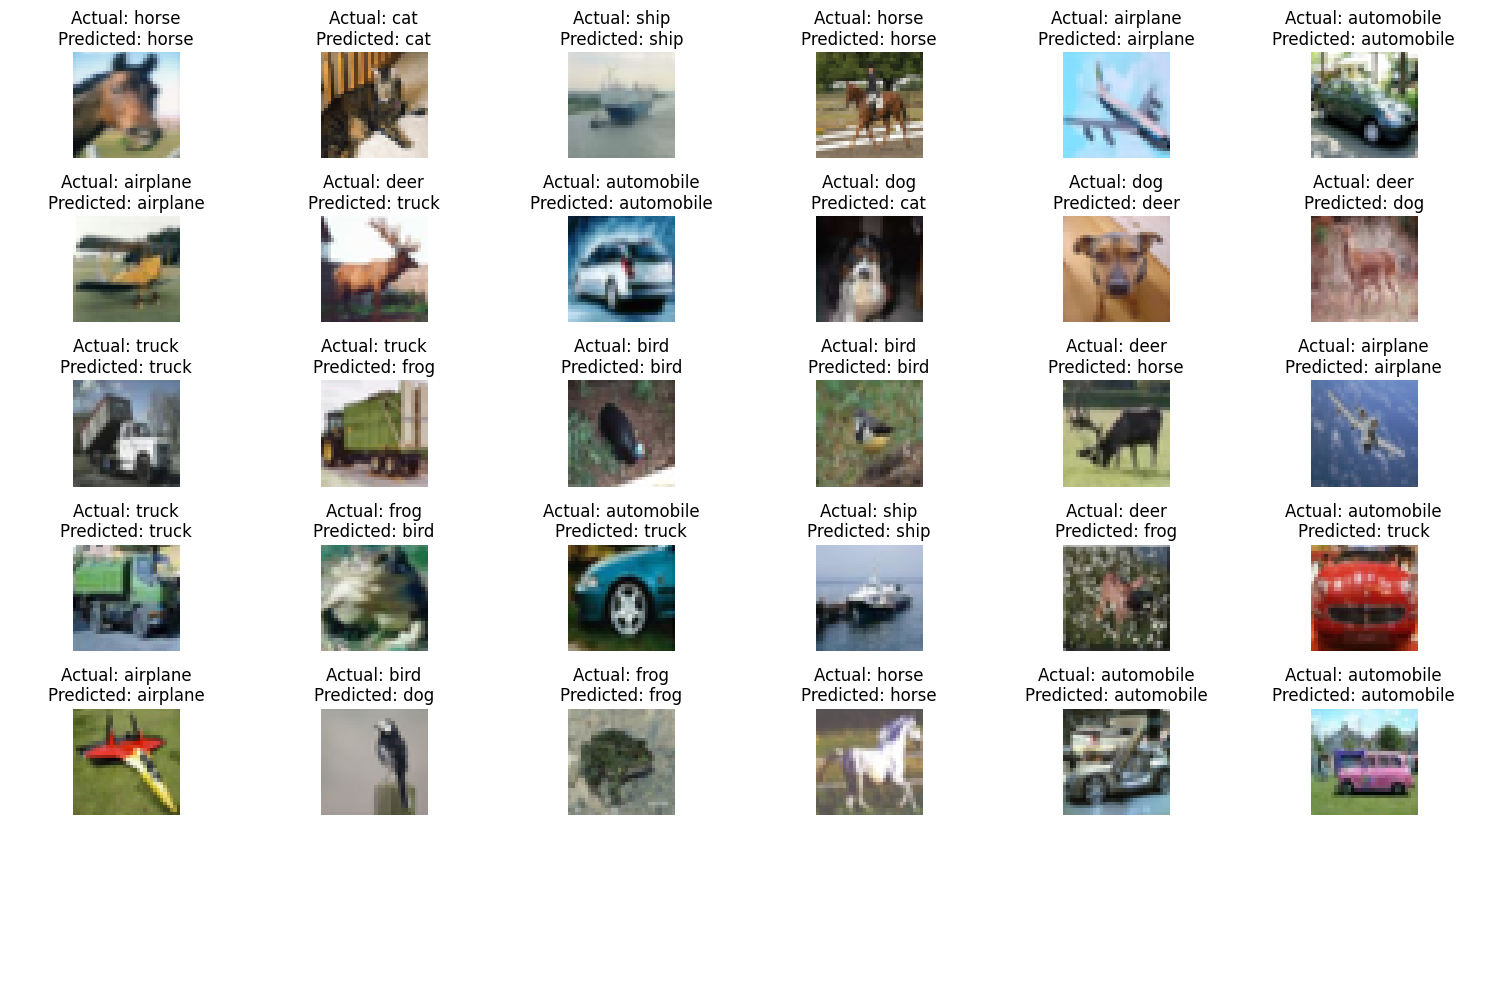

In [ ]:
num_images_to_display = 30  # Number of images to display
num_columns  = 6
num_rows = 6
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
fig , axes = plt.subplots(num_rows,num_columns,figsize=(15,10))
for i,ax in enumerate(axes.flat):
  if i < num_images_to_display:
    ax.imshow(x_test[i])
    actual_label = class_names[np.argmax(y_test[i])]
    predicted_label = class_names[np.argmax(pred[i])]
    ax.set_title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    ax.axis('off')
  else:
    ax.axis('off')
plt.tight_layout()
plt.show()

# New section